In [ ]:
# 1. 시스템 패키지 업데이트 및 필수 빌드 도구 확인
!apt-get update && apt-get install -y build-essential

# 2. PyTorch 및 관련 라이브러리 (25.10 런타임 기본 설치와 정합성 유지)
# 기존 설치된 것과 충돌을 피하기 위해 명시적으로 설치
!pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

# 3. NuScenes 및 SimpleBEV 필수 의존성
# 버전 충돌의 주범인 numpy와 setuptools 버전을 고정하거나 최신 유지
!pip install nuscenes-devkit pyquaternion efficientnet-pytorch==0.7.1
!pip install opencv-python tensorboard scipy segmentation-models-pytorch
!pip install lyft-dataset-sdk # NuScenes와 유사 구조에서 자주 참조됨

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Get:11 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,297 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-driver

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 160.1 MB/s eta 0:00:00
^C


In [1]:
import os
if not os.path.exists('simple_bev'):
    !git clone https://github.com/aharley/simple_bev.git
%cd simple_bev

# 5. 경로 등록 (이게 안 되면 모듈 못 찾음)
import sys
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"PyTorch Version: {torch.__version__}")

Cloning into 'simple_bev'...
remote: Enumerating objects: 375, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 375 (delta 42), reused 45 (delta 41), pack-reused 326 (from 1)
Receiving objects: 100% (375/375), 144.00 KiB | 2.77 MiB/s, done.
Resolving deltas: 100% (224/224), done.
/content/simple_bev
CUDA Available: True
PyTorch Version: 2.8.0+cu126


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import os
# SimpleBEV가 인식할 표준 경로 생성
LOCAL_DATA_ROOT = '/content/data/sets/nuscenes'
os.makedirs(LOCAL_DATA_ROOT, exist_ok=True)

In [4]:
import os
from google.colab import drive

# 1. 드라이브 마운트
drive.mount('/content/drive')

# 2. 경로 설정
DRIVE_PATH = '/content/drive/MyDrive/data/sets/nuscenes'
LOCAL_DATA_ROOT = '/content/data/sets/nuscenes'

# 로컬 루트 폴더 생성
os.makedirs(LOCAL_DATA_ROOT, exist_ok=True)

# 3. 연결(Symbolic Link) 생성 루틴
# 복사하지 않고 주소만 연결한다. 실행 즉시 끝난다.
def link_data(source, target):
    if os.path.exists(source):
        if not os.path.exists(target):
            os.symlink(source, target)
            print(f"✅ Linked: {os.path.basename(source)}")
        else:
            print(f"ℹ️ Already exists: {os.path.basename(source)}")
    else:
        print(f"❌ Source not found: {source}")

# 주요 폴더들 연결
folders = ['maps', 'samples', 'sweeps', 'v1.0-mini']
for folder in folders:
    link_data(f"{DRIVE_PATH}/{folder}", f"{LOCAL_DATA_ROOT}/{folder}")

# .pkl 파일들도 한 번에 연결
!ln -s {DRIVE_PATH}/*.pkl {LOCAL_DATA_ROOT}/

print("\n🚀 모든 데이터 연결 완료! 이제 복사 기다릴 필요 없다.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Linked: maps
✅ Linked: samples
✅ Linked: sweeps
✅ Linked: v1.0-mini

🚀 모든 데이터 연결 완료! 이제 복사 기다릴 필요 없다.


In [6]:
# 1. 기존 라이브러리 삭제 및 안정 버전 설치
!pip uninstall -y scipy numpy
!pip install "numpy<2.0" "scipy<1.13.0" nuscenes-devkit

# 2. 설치 완료 후 런타임 재시작이 필수다!

Found existing installation: scipy 1.16.2
Uninstalling scipy-1.16.2:
  Successfully uninstalled scipy-1.16.2
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.3 MB/s eta 0:00:00
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 89.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompa

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 4.861 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


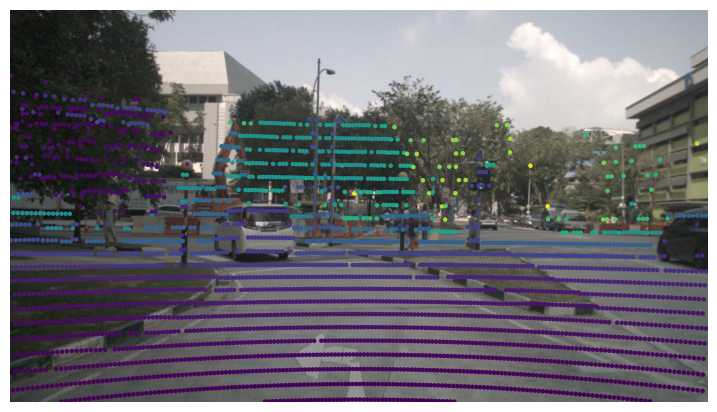

✅ NuScenes SDK 로드 성공!


In [1]:
from nuscenes.nuscenes import NuScenes

# 데이터셋 경로 및 버전 확인
try:
    nusc = NuScenes(version='v1.0-mini', dataroot='/content/data/sets/nuscenes', verbose=True)
    # 샘플 데이터 하나만 렌더링해서 확인
    my_sample = nusc.sample[10]
    nusc.render_pointcloud_in_image(my_sample['token'], pointsensor_channel='LIDAR_TOP')
    print("✅ NuScenes SDK 로드 성공!")
except Exception as e:
    print(f"❌ 에러 발생: {e}")
    print("데이터셋이 /content/data/sets/nuscenes/v1.0-mini 경로에 정확히 있는지 확인해라.")

In [2]:
import os
import shutil

# 1. 최상위 경로로 이동
%cd /content

# 2. 잘못 클론된 폴더가 있다면 정상 위치로 이동
wrong_path = '/content/data/sets/nuscenes/simple_bev'
correct_path = '/content/simple_bev'

if os.path.exists(wrong_path):
    print(f"💡 잘못된 경로에서 폴더 발견. {correct_path}로 이동한다.")
    if os.path.exists(correct_path):
        shutil.rmtree(correct_path) # 기존에 잘못 생성된 게 있으면 삭제
    shutil.move(wrong_path, correct_path)

# 3. 폴더로 이동 시도
if os.path.exists(correct_path):
    %cd {correct_path}
    print(f"✅ 현재 위치: {os.getcwd()}")
    !ls train_nuscenes.py # 파일이 있는지 최종 확인
else:
    print("❌ 폴더가 여전히 없다. 다시 클론한다.")
    !git clone https://github.com/aharley/simple_bev.git
    %cd /content/simple_bev

# 4. 경로 변수 설정 (파이썬 내부에서 사용할 경로 등록)
import sys
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

/content
/content/simple_bev
✅ 현재 위치: /content/simple_bev
train_nuscenes.py


In [3]:
# 에러의 원인: Lyft SDK가 설치되지 않음
!pip install lyft-dataset-sdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 4.1 MB/s eta 0:00:00
  Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 8.9 MB/s eta 0:00:00
Using cached numpy-2.2.6-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 126.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.0/55.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 10.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
  

In [1]:
!pip install tensorboardX

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 2.8 MB/s eta 0:00:00


In [2]:
import os

# 1. 스크립트가 요구하는 경로 생성 (/content/nuscenes/mini)
target_dir = '/content/nuscenes/mini'
os.makedirs(target_dir, exist_ok=True)

# 2. 실제 데이터 위치 정의
# 아까 네가 옮긴 위치가 /content/data/sets/nuscenes/mini 일 확률이 높다.
actual_data_base = '/content/data/sets/nuscenes/mini'

# 3. 심볼릭 링크 생성 (원본 데이터는 그대로 두고 길만 열어줌)
# v1.0-mini, samples, sweeps, maps 등을 연결
sub_folders = ['v1.0-mini', 'samples', 'sweeps', 'maps']

for folder in sub_folders:
    src = os.path.join(actual_data_base, folder)
    dst = os.path.join(target_dir, folder)

    if os.path.exists(src):
        if not os.path.exists(dst):
            os.symlink(src, dst)
            print(f"🔗 Linked: {folder}")
    else:
        # 혹시 mini 폴더가 중첩되지 않았을 경우를 대비해 상위 폴더 체크
        src_alt = src.replace('/mini/', '/')
        if os.path.exists(src_alt) and not os.path.exists(dst):
            os.symlink(src_alt, dst)
            print(f"🔗 Linked (Alt): {folder}")

# 4. .pkl 파일들도 링크
!ln -s /content/data/sets/nuscenes/mini/*.pkl /content/nuscenes/mini/ 2>/dev/null

print("\n✅ 경로 정화 완료. 이제 다시 돌려봐.")

🔗 Linked (Alt): v1.0-mini
🔗 Linked (Alt): samples
🔗 Linked (Alt): sweeps
🔗 Linked (Alt): maps

✅ 경로 정화 완료. 이제 다시 돌려봐.


In [3]:
# 1. 문제가 되는 utils/vox.py 파일 수정
# numpy 값을 float()로 감싸서 PyTorch가 인식할 수 있는 기본 스칼라로 변환한다.

import os

file_path = '/content/simple_bev/utils/vox.py'

# 파일 내용 읽기
with open(file_path, 'r') as f:
    lines = f.readlines()

# 문제의 라인들을 찾아 수정 (Line 90~93 근처)
with open(file_path, 'w') as f:
    for line in lines:
        # numpy 할당 부분을 Python float로 강제 형변환
        line = line.replace('-self.XMIN-vox_size_X/2.0', 'float(-self.XMIN-vox_size_X/2.0)')
        line = line.replace('-self.YMIN-vox_size_Y/2.0', 'float(-self.YMIN-vox_size_Y/2.0)')
        line = line.replace('-self.ZMIN-vox_size_Z/2.0', 'float(-self.ZMIN-vox_size_Z/2.0)')
        f.write(line)

print("✅ utils/vox.py 패치 완료. 이제 다시 돌려봐.")

✅ utils/vox.py 패치 완료. 이제 다시 돌려봐.


In [4]:
import os

file_path = '/content/simple_bev/utils/vox.py'

# 1. 파일 읽기
with open(file_path, 'r') as f:
    content = f.read()

# 2. NumPy 값을 Torch Tensor(CUDA)에 할당할 때 발생하는 에러 방지를 위해 float() 캐스팅 추가
# 센터링 연산 수정
content = content.replace('-self.XMIN-vox_size_X/2.0', 'float(-self.XMIN-vox_size_X/2.0)')
content = content.replace('-self.YMIN-vox_size_Y/2.0', 'float(-self.YMIN-vox_size_Y/2.0)')
content = content.replace('-self.ZMIN-vox_size_Z/2.0', 'float(-self.ZMIN-vox_size_Z/2.0)')

# 복셀 사이즈 역수 연산 수정 (97번 라인 에러 지점)
content = content.replace('1./vox_size_X', 'float(1./vox_size_X)')
content = content.replace('1./vox_size_Y', 'float(1./vox_size_Y)')
content = content.replace('1./vox_size_Z', 'float(1./vox_size_Z)')

# 3. 파일 쓰기
with open(file_path, 'w') as f:
    f.write(content)

print("✅ [vox.py] 모든 잠재적 Type 에러 패치 완료.")

✅ [vox.py] 모든 잠재적 Type 에러 패치 완료.


In [5]:
# 1. 폴더 이동
%cd /content/simple_bev

# 2. 파일이 있는지 최종 확인 (train_nuscenes.py가 목록에 나와야 함)
!ls

/content/simple_bev
eval_lyft.py	       eval.sh		 nets		     train_nuscenes.py
eval_lyft.sh	       get_rad_model.sh  nuscenesdataset.py  train.sh
eval_nuscenes.py       get_rgb_model.sh  README.md	     utils
eval_over_distance.py  LICENSE		 requirements.txt    vis_collage.py
eval_over_distance.sh  lift.sh		 saverloader.py      vis_nuscenes.py
eval_runner.sh	       lyft_runner.sh	 train_lyft.py


In [6]:
# 1. 기존의 꼬인 링크들 싹 다 삭제
!rm -rf /content/data/sets/nuscenes/mini
!rm -rf /content/data/sets/nuscenes/sweeps
!rm -rf /content/data/sets/nuscenes/samples

# 2. 드라이브에서 직접 '통째로' 연결 (이게 가장 확실함)
# DRIVE_PATH는 네 실제 드라이브 경로로 수정
DRIVE_PATH="/content/drive/MyDrive/data/sets/nuscenes"

!ln -s {DRIVE_PATH}/sweeps /content/data/sets/nuscenes/sweeps
!ln -s {DRIVE_PATH}/samples /content/data/sets/nuscenes/samples

# 3. 확인: 이제 LIDAR_TOP이 보이는가?
!ls -d /content/data/sets/nuscenes/sweeps/*

/content/data/sets/nuscenes/sweeps/CAM_BACK
/content/data/sets/nuscenes/sweeps/CAM_BACK_LEFT
/content/data/sets/nuscenes/sweeps/CAM_BACK_RIGHT
/content/data/sets/nuscenes/sweeps/CAM_FRONT
/content/data/sets/nuscenes/sweeps/CAM_FRONT_LEFT
/content/data/sets/nuscenes/sweeps/CAM_FRONT_RIGHT
/content/data/sets/nuscenes/sweeps/LIDAR_TOP
/content/data/sets/nuscenes/sweeps/RADAR_BACK_LEFT
/content/data/sets/nuscenes/sweeps/RADAR_BACK_RIGHT
/content/data/sets/nuscenes/sweeps/RADAR_FRONT
/content/data/sets/nuscenes/sweeps/RADAR_FRONT_LEFT
/content/data/sets/nuscenes/sweeps/RADAR_FRONT_RIGHT


In [7]:
# 원본 폴더에 데이터가 있는지 확인
!ls -d /content/data/sets/nuscenes/sweeps
!ls /content/data/sets/nuscenes/sweeps | head -n 5

/content/data/sets/nuscenes/sweeps
CAM_BACK
CAM_BACK_LEFT
CAM_BACK_RIGHT
CAM_FRONT
CAM_FRONT_LEFT


In [8]:
# 1. 부모 디렉토리를 포함하여 전체 경로를 생성 (-p 옵션 필수)
!mkdir -p /content/data/sets/nuscenes/mini/

# 2. 원본 데이터 위치(SOURCE)가 어디인지 확인해라.
# 아래는 예시이므로, 실제 nuscenes 데이터가 압축 해제된 경로로 수정해서 실행해라.
# ln -s [원본데이터경로] [링크를걸위치]
!ln -s /content/drive/MyDrive/nuscenes/sweeps /content/data/sets/nuscenes/mini/sweeps

# 3. 연결 확인
!ls -ld /content/data/sets/nuscenes/mini/sweeps

lrwxrwxrwx 1 root root 38 Jan 15 07:38 /content/data/sets/nuscenes/mini/sweeps -> /content/drive/MyDrive/nuscenes/sweeps


In [9]:
# 부모 디렉토리 생성
!mkdir -p /content/data/sets/nuscenes/mini/

# 기존에 잘못 연결된 게 있어도 -sf로 강제 덮어쓰기!
!ln -sf /content/data/sets/nuscenes/samples /content/data/sets/nuscenes/mini/samples
!ln -sf /content/data/sets/nuscenes/sweeps /content/data/sets/nuscenes/mini/sweeps
!ln -sf /content/data/sets/nuscenes/v1.0-mini /content/data/sets/nuscenes/mini/v1.0-mini

# 연결 상태 확인 (제대로 됐으면 화살표가 뜬다!)
!ls -lh /content/data/sets/nuscenes/mini/

total 0
lrwxrwxrwx 1 root root 35 Jan 15 07:38 samples -> /content/data/sets/nuscenes/samples
lrwxrwxrwx 1 root root 34 Jan 15 07:38 sweeps -> /content/data/sets/nuscenes/sweeps
lrwxrwxrwx 1 root root 37 Jan 15 07:38 v1.0-mini -> /content/data/sets/nuscenes/v1.0-mini


In [10]:
# 1. maps 폴더도 mini 하위로 강제 연결!
!ln -sf /content/data/sets/nuscenes/maps /content/data/sets/nuscenes/mini/maps

# 2. 제대로 연결됐는지 다시 전체 구조 확인!
!ls -F /content/data/sets/nuscenes/mini/

maps@  samples@  sweeps@  v1.0-mini@


In [12]:
!python train_nuscenes.py \
--exp_name simplebev_m1_aug_max_v1 \
--device_ids '[0]' \
--dset mini \
--batch_size 1 \
--max_iters 1300 \
--val_freq 100 \
--save_freq 100 \
--lr 5e-4 \
--res_scale 2 \
--encoder_type res101 \
--use_lidar True \
--data_dir /content/data/sets/nuscenes/ \
--log_dir logs_m1_aug \
--ckpt_dir checkpoints_m1 \
--rand_flip True \
--rand_crop True \
--do_rgbcompress True

model_name 1x5_5e-04_simplebev_m1_aug_max_v1_07:40:25
loading nuscenes...
making parser...
indices (323, 1)
NuscData: 323 samples. Split: train.
                   Augmentation Conf: {'crop_offset': 89, 'resize_lim': [0.8, 1.2], 'final_dim': (448, 800), 'H': 900, 'W': 1600, 'cams': ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT'], 'ncams': 6}
indices (81, 1)
NuscData: 81 samples. Split: val.
                   Augmentation Conf: {'crop_offset': 89, 'resize_lim': [0.8, 1.2], 'final_dim': (448, 800), 'H': 900, 'W': 1600, 'cams': ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT'], 'ncams': 6}
data ready
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: Us

In [14]:
# 1. 드라이브 내 저장 폴더 생성
!mkdir -p '/content/drive/MyDrive/simple_bev_project/final_results'

# 2. 확인된 정확한 경로로 파일 복사
!cp '/content/simple_bev/checkpoints_m1/1x5_5e-04_simplebev_m1_aug_max_v1_07:40:25/best/model-000001300.pth' \
    '/content/drive/MyDrive/simple_bev_project/final_results/'

# 3. 제대로 복사됐는지 확인
!ls -lh '/content/drive/MyDrive/simple_bev_project/final_results/model-000001300.pth'

-rw------- 1 root root 481M Jan 15 08:03 /content/drive/MyDrive/simple_bev_project/final_results/model-000001300.pth


In [15]:
# 1. mini/maps 아래에 expansion 폴더 생성
!mkdir -p /content/data/sets/nuscenes/mini/maps/expansion

# 2. 원본 maps에 있는 모든 .json 파일들을 expansion 폴더로 링크(연결)
# (이미 파일이 있다면 -sf로 강제 실행!)
!ln -sf /content/data/sets/nuscenes/maps/*.json /content/data/sets/nuscenes/mini/maps/expansion/

# 3. 제대로 들어갔는지 확인해라!
!ls -R /content/data/sets/nuscenes/mini/maps/expansion/

/content/data/sets/nuscenes/mini/maps/expansion/:
boston-seaport.json	       singapore-onenorth.json
singapore-hollandvillage.json  singapore-queenstown.json


In [19]:
# 2000 step 가중치가 들어있는 폴더를 지정함
!CUDA_VISIBLE_DEVICES=0 python /content/simple_bev/vis_nuscenes.py \
  --init_dir='/content/drive/MyDrive/4x5_5e-4s_simplebev_full_run_v1_04:54:40/' \
  --data_dir='/content/data/sets/nuscenes/' \
  --img_dir='/content/drive/MyDrive/simple_bev_project/vis_results_v2000' \
  --dset='mini' \
  --batch_size=1 \
  --max_iters=10 \
  --res_scale=2 \
  --encoder_type='res101' \
  --use_lidar=True \
  --do_rgbcompress=True

model_name 1t40_debug_08:27:19
resolution: (448, 800)
loading nuscenes...
making parser...
indices (11, 40)
NuscData: 11 samples. Split: train.
                   Augmentation Conf: {'crop_offset': 0, 'resize_lim': [1.0, 1.0], 'final_dim': (448, 800), 'H': 900, 'W': 1600, 'cams': ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT'], 'ncams': 6}
indices (3, 40)
NuscData: 3 samples. Split: val.
                   Augmentation Conf: {'crop_offset': 0, 'resize_lim': [1.0, 1.0], 'final_dim': (448, 800), 'H': 900, 'W': 1600, 'cams': ['CAM_FRONT_LEFT', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_LEFT', 'CAM_BACK', 'CAM_BACK_RIGHT'], 'ncams': 6}
data ready
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWa

In [ ]:
# 1. 대상 백업 폴더 생성
!mkdir -p "/content/drive/MyDrive/simple_bev_project/vis_results_backup"

# 2. 모든 파일 및 하위 폴더 복제 (-r: recursive, -v: verbose)
!cp -rv "/content/drive/MyDrive/simple_bev_project/vis_results/"* "/content/drive/MyDrive/simple_bev_project/vis_results_backup/"

# 3. 복제 완료 확인
!ls -lh "/content/drive/MyDrive/simple_bev_project/vis_results_backup"

'/content/drive/MyDrive/simple_bev_project/vis_results/1t40_debug_07:58:24' -> '/content/drive/MyDrive/simple_bev_project/vis_results_backup/1t40_debug_07:58:24'
'/content/drive/MyDrive/simple_bev_project/vis_results/1t40_debug_07:58:24/events.out.tfevents.1768377504.4fbc059380f4' -> '/content/drive/MyDrive/simple_bev_project/vis_results_backup/1t40_debug_07:58:24/events.out.tfevents.1768377504.4fbc059380f4'
'/content/drive/MyDrive/simple_bev_project/vis_results/1t40_debug_08:06:20' -> '/content/drive/MyDrive/simple_bev_project/vis_results_backup/1t40_debug_08:06:20'
'/content/drive/MyDrive/simple_bev_project/vis_results/1t40_debug_08:06:20/events.out.tfevents.1768377980.4fbc059380f4' -> '/content/drive/MyDrive/simple_bev_project/vis_results_backup/1t40_debug_08:06:20/events.out.tfevents.1768377980.4fbc059380f4'
'/content/drive/MyDrive/simple_bev_project/vis_results/1t40_debug_08:06:29' -> '/content/drive/MyDrive/simple_bev_project/vis_results_backup/1t40_debug_08:06:29'
'/content/driv